<a href="https://colab.research.google.com/github/lalawee/special-octo-barnacle/blob/main/bandit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Armed Bandit Problem**
This classic RL problem demonstrates the
exploration–exploitation tradeoff dilemma.

Imagine a gambler at a row of slot
machines ("one-armed bandits") deciding
which ones to play, how many times to
play each one and in which order to play
them, and whether to continue with current machine or try different one.

In the problem, each slot machine provides a random reward from a probability distribution specific to that machine, that is not known a priori. The objective of the gambler is to maximize the sum of rewards earned through a sequence of lever pulls.

The crucial tradeoff the gambler faces at each trial is between "exploitation" of the machine that has the highest expected payoff calculated thus far and "exploration" to get more information about the expected payoffs of the other machines in the hope to get even better payoffs. This trade-off between exploration and exploitation is constantly faced in RL.

In [32]:
import numpy as np
import matplotlib.pyplot as plt

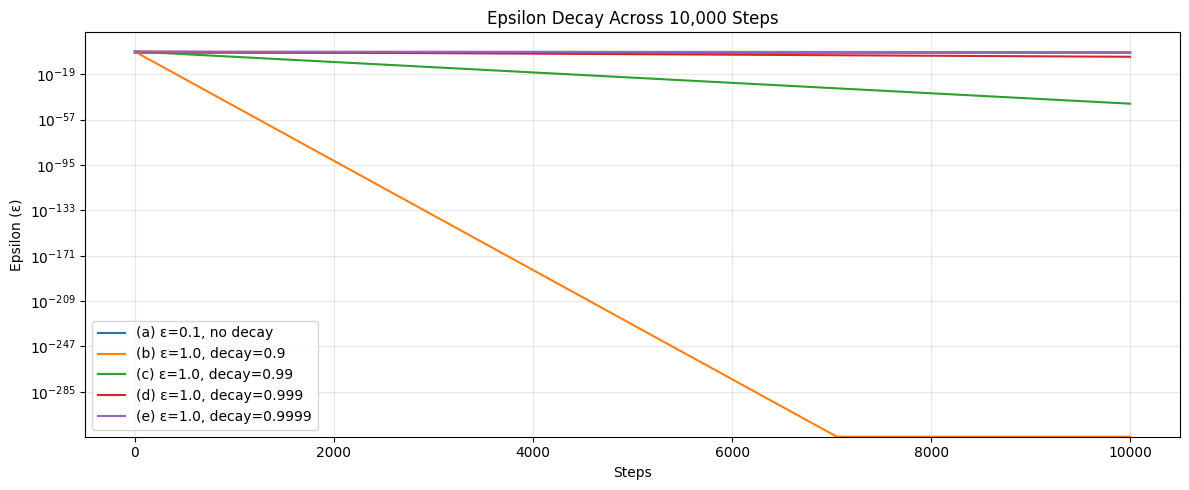

In [33]:
# TASK  1 to visualize the  relationship across 5 cases...

cases = [
    {"label": "a", "desc": "ε=0.1, no decay",    "eps0": 0.1, "decay": 1.0},
    {"label": "b", "desc": "ε=1.0, decay=0.9",   "eps0": 1.0, "decay": 0.9},
    {"label": "c", "desc": "ε=1.0, decay=0.99",  "eps0": 1.0, "decay": 0.99},
    {"label": "d", "desc": "ε=1.0, decay=0.999", "eps0": 1.0, "decay": 0.999},
    {"label": "e", "desc": "ε=1.0, decay=0.9999","eps0": 1.0, "decay": 0.9999},
]

plt.figure(figsize=(12, 5))

for case in cases:
    eps = case["eps0"]
    history = []
    for _ in range(N_STEPS):
        history.append(eps)
        eps *= case["decay"]
    plt.plot(history, label=f"({case['label']}) {case['desc']}")

plt.xlabel("Steps")
plt.ylabel("Epsilon (ε)")
plt.title("Epsilon Decay Across 10,000 Steps")
plt.legend()
plt.yscale("log")   # remove this line if you want linear scale
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
"""
Q: What can we say about (d) and (e) vs (b) and (c) in later steps?
Cases (b) and (c) decay so aggressively that ε → ~0 well before step 10,000 — the agent essentially stops exploring entirely and is locked into whatever arm it thinks is best.
 Cases (d) and (e) retain meaningful ε much longer,
so the agent still occasionally tries random arms even late in training. Case (e) (decay=0.9999) still has ε ≈ 0.37 at step 10,000!


Q: How would average total reward compare?
(d) and (e) should yield higher average total reward than (b) and (c), because:
(b) decays so fast (~100 steps) it may commit to a suboptimal arm before gathering enough data
Slow decay = more chances to discover the best arm (arm 9, p=0.9) before exploiting it
The tradeoff is that (e) might "waste" pulls on random arms late in training, but this is minor compared to the risk of being stuck on a bad arm forever
"""

In [34]:
#
# Define Constants
#
N_ARMS=10 #10 "bandits" in a row
N_STEPS = 10000 #10K steps
EPS = 0.1 #Epsilon

N_EPISODES=1000


avg_rewards = []

In [35]:
#
# Define the Multi-Armed Bandit class
# (1 row of N_ARMS slot machines)
#
class MultiArmedBandit:
    # Initializer
    def __init__(self):
       # probability distribution specific to the N_ARMS slot machine (not known before hand)
       self.probabilities=np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

    # Simulate a single pull of slot machine arm
    # returns a win 1 or lose 0
    def pull(self, arm):
        return 1 if np.random.rand() < self.probabilities[arm] else 0

In [36]:
#
# Define the Agent using the Epsilon-Greedy strategy
#
class EpsilonGreedyAgent:
    # Initializer
    def __init__(self, epsilon, decay):
        self.epsilon = epsilon
        self.decay =  decay
        self.est_returns = np.zeros(N_ARMS)  # Estimated expected returns for each arm
        self.arm_counts = np.zeros(N_ARMS)  # Number of times each arm was pulled
        self.total_rewards = np.zeros(N_ARMS) # Total rewards accumulated for each slot machine

    # Select an arm to pull based on the Epsilon-Greedy strategy
    def select_arm(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(N_ARMS)  # Explore: Return a random arm 0 to N_ARMS-1
        else:
            return np.argmax(self.est_returns)  # Exploit: Return the index of arm with best returns thus far

    # Update estimated expected returns of an arm
    # (reward is 1 or 0)
    def update(self, arm, reward):

        self.epsilon *=  self.decay

        self.arm_counts[arm] += 1
        self.total_rewards[arm] += reward
        self.est_returns[arm] = self.total_rewards[arm] / self.arm_counts[arm]

In [37]:

for case in cases:
    episode_rewards = []

    for episode in range(N_EPISODES):
        bandits = MultiArmedBandit()
        agent = EpsilonGreedyAgent(case["eps0"], decay=case["decay"])

        for step in range(N_STEPS):
            arm = agent.select_arm()
            reward = bandits.pull(arm)
            agent.update(arm, reward)

        episode_rewards.append(sum(agent.total_rewards))

    avg = np.mean(episode_rewards)
    avg_rewards.append(avg)
    print(f"Case ({case['label']}) {case['desc']}: avg total reward = {avg:.1f}")

Case (a) ε=0.1, no decay: avg total reward = 8484.1
Case (b) ε=1.0, decay=0.9: avg total reward = 8056.7
Case (c) ε=1.0, decay=0.99: avg total reward = 8856.9
Case (d) ε=1.0, decay=0.999: avg total reward = 8549.2
Case (e) ε=1.0, decay=0.9999: avg total reward = 6155.7


In [41]:
"""
Q1: Ability to find a random arm in later steps — (d) and (e) vs (b) and (c)?
(d) and (e) retain much higher epsilon in later steps, meaning the agent is still exploring frequently near step 10,000.
(b) and (c) have decayed to near-zero by then, so the agent has stopped exploring and is purely exploiting its best known arm.
So (d) and (e) are much more likely to pull a random arm late in training.


Q2: How do average total rewards compare — was your expectation correct?
(c) wins with 8856 — it decays at just the right pace, exploring enough early on to find arm 9, then exploiting it for the majority of steps
(a) comes second at 8484 — constant ε=0.1 is a solid baseline
(d) is similar to (a) at 8549
(b) underperforms at 8056 — decays too fast, risks committing early before finding the best arm
(e) is worst at 6155 — decays so slowly that it's still wasting pulls on random arms far too late

So the earlier expectation that "slower decay = better" was partially wrong. There's a sweet spot — decay fast enough to exploit the best arm for most of the 10,000 steps,
 but slow enough to have explored sufficiently first. (c) hits that sweet spot best for this particular bandit setup.

"""

'\nQ1: Ability to find a random arm in later steps — (d) and (e) vs (b) and (c)?\n(d) and (e) retain much higher epsilon in later steps, meaning the agent is still exploring frequently near step 10,000. \n(b) and (c) have decayed to near-zero by then, so the agent has stopped exploring and is purely exploiting its best known arm. \nSo (d) and (e) are much more likely to pull a random arm late in training.\n\n\nQ2: How do average total rewards compare — was your expectation correct?\n(c) wins with 8856 — it decays at just the right pace, exploring enough early on to find arm 9, then exploiting it for the majority of steps\n(a) comes second at 8484 — constant ε=0.1 is a solid baseline\n(d) is similar to (a) at 8549\n(b) underperforms at 8056 — decays too fast, risks committing early before finding the best arm\n(e) is worst at 6155 — decays so slowly that it\'s still wasting pulls on random arms far too late\n\nSo the earlier expectation that "slower decay = better" was partially wrong. 

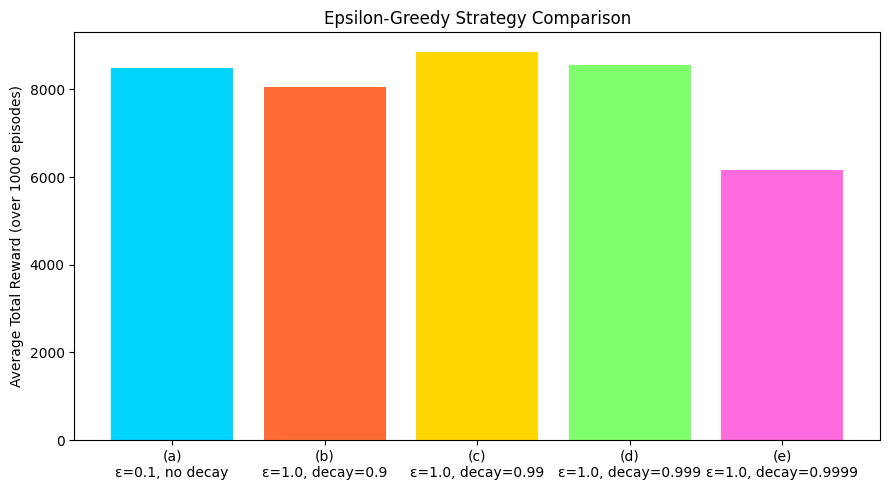

In [38]:
# Bar chart
plt.figure(figsize=(9, 5))
labels = [f"({c['label']})\n{c['desc']}" for c in cases]
plt.bar(labels, avg_rewards, color=["#00d4ff","#ff6b35","#ffd700","#7fff6b","#ff6bdc"])
plt.ylabel("Average Total Reward (over 1000 episodes)")
plt.title("Epsilon-Greedy Strategy Comparison")
plt.tight_layout()
plt.show()

In [39]:
print(f"Rewards of Each Arm = {agent.total_rewards}")
print(f"Arm Counts = {agent.arm_counts}")
print(f"Est Returns = {agent.est_returns}")
print(f"Total rewards = {sum(agent.total_rewards)}")

Rewards of Each Arm = [   0.   61.  109.  193.  246.  330.  386.  439.  506. 3828.]
Arm Counts = [ 645.  626.  642.  633.  642.  676.  645.  628.  621. 4242.]
Est Returns = [0.         0.09744409 0.16978193 0.30489731 0.38317757 0.48816568
 0.59844961 0.69904459 0.81481481 0.90240453]
Total rewards = 6098.0
